# Applied Math 10: Computing for Science and Engineering

## Section 08 : Data Fitting

**Fall 2020**<br/>

In [1]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## 1. Why do we need  `meshgrid`?

`Numpy`'s `meshgrid` returns a rectangular matrix out of two given one-dimensional arrays. For example, we have a 1D array (vector) of $x$ points an equal number of $y$ points, and we want to evaluate a function on a grid of $x$ and $y$ points. We create $(X,Y)$ points as shown. 

See: [`numpy meshgrid`](!https://numpy.org/doc/stable/reference/generated/numpy.meshgrid.html)

![](meshgrid.png)

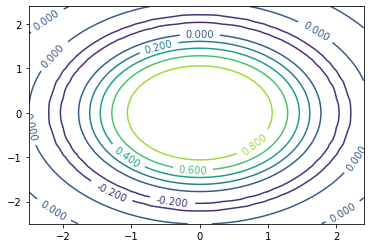

[-0.4 -0.2  0.   0.2  0.4  0.6  0.8  1. ]


In [2]:
# initial points
x = np.arange(-2.5, 2.5, 0.1)
y = np.arange(-2.5, 2.5, 0.1)

# meshgrid points
X, Y = np.meshgrid(x, y, sparse=True)

# define functions of two variables, X,Y: z(X,Y)
z = np.sin(X**2 + Y**2) / (X**2 + Y**2)

# create contour lines
fig, ax = plt.subplots()

h = ax.contour(x,y,z)
ax.clabel(h, levels=h.levels, inline=True,  fontsize=10) #fmt=fmt,, 
plt.show()

print(h.levels)

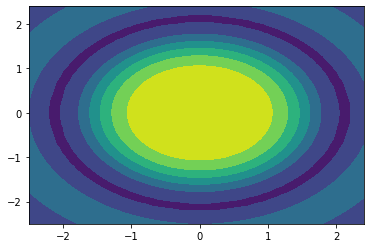

In [3]:
# create filled contour
fig, ax = plt.subplots()
h = ax.contourf(x,y,z)
plt.show()

## 2. Fitting our second set of data points

- Let's import the set of (x, y) points by loading the following two data files: `AM10_L08_2_x.txt` and `AM10_L08_2_y.txt` in variables `x_2` and `y_2` respectively.
- Again, check to see if what you see is what you get. Save the array dimension in a variable named `Nd_2` for later use.
- Lastly let's plot the two arrays. 

#### We will need these functions from Lab_08

In [4]:
def fit_and_plot_func(func, x, y, title):
    """
       Fit and plot a polynomial. 
       Arguments: poly function, x data, y data
       Returns: the plot of the fit
        """
    
    # first find the coefficients
    popt, pcov = curve_fit(func, x, y)
    num_vars = len(popt)
    print(f'num of variables={num_vars}')
    
    # Plot the polynomial and calculate rmse
    ffit=func(x,*popt) 
    
    # calculate the rmse
    Nd=np.shape(x)
    ovrNd=(1.0/np.sqrt(Nd))
    rmsefit=ovrNd*np.sqrt(np.sum((ffit-y)**2))

    print(f'RMSE={rmsefit}')
    plt.figure(figsize=(8,5))
    plt.title(title, fontsize=fonts)
    plt.scatter(x,y, facecolor = 'blue', alpha = 0.6, label='data')
    
    plt.plot(x,ffit,'g', label='fit') 
    plt.xlabel(r'$x$', fontsize=fonts)
    plt.ylabel(r'$f(x)$', fontsize=fonts)
    plt.legend()
    plt.show();

In [5]:
def poly(x:np.array, *coeffs):
    """Defines a polynomial of variable degree. 
       Arguments: x = array of data points, 
       *coeffs = ordered set of coefficients corresponding to polynomial exponents 
                 in order of descending powers
       Returns: an array of the number values of the polynomial on the data points
    """
    
    p = np.zeros(len(x))
    # we reverse the coeff array to match the a*x^n + b*x^(n-1) + ... + constant*x^0
    coeffs = coeffs[::-1]
    for degree, coeff in enumerate(coeffs):
        p += coeff * x**degree
    return p

# # Define the 2nd degree using the generic function
# def poly2(x,a,b,c):
#     return poly(x,a,b,c)

#### Load and print the new dataset

In [6]:
x_2=np.loadtxt('AM10_L08_2_x.txt')
y_2=np.loadtxt('AM10_L08_2_y.txt')

In [ ]:
# your code here


### First we will try with polynomials

Remember, `scipy.curve_fit` takes a function as its input and finds that function's arguments. So, effectively we have to make an educated guess as to the type of function from which our data were produced. Was it polynomial? Was it exponential? What is the formula for $f(x)$? 

### Problem 1: 
Combine the `fit_and_plot_func()` with the custom polynomial function `poly` to try and fit various degree polynomials to the data above. Start with a 4th degree, then a 6th degree, and go higher, as needed.<BR><BR>
**Hint:** For example, a 4th degree polynomial could be defined as follows: 
```
def poly4(x,a,b,c,d,e):
    return poly(x,a,b,c,d,e)
```

In [9]:
# your code here


### Let's try with a sin() 

On second thought, this plot looks more like a sin() function than a polynomial. Try to guess the $A$, $\omega$, and $\phi$ parameters in the following formula:<BR><BR>
$$ {\rm P(t)} = A+\sin(\omega\cdot t) + \phi) 
$$ 

### Problem 2:
Use `curve_fit` to fit the coefficients and plot the sinusoidal function above. Do you have a better fit?

In [11]:
# your code here


**That looks a lot better!** It's always good to have some idea of the underlying structure of our data. That is called domain knowledge!